In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages


In [2]:
path_output = 'simulation_output/'
simulation_name_krig = os.listdir(path_output)[0:-1:2]
simulation_name = os.listdir(path_output)[1::2]

In [3]:
simulation_name

['realisation0_simu.pickle',
 'realisation100_simu.pickle',
 'realisation101_simu.pickle',
 'realisation102_simu.pickle',
 'realisation103_simu.pickle',
 'realisation104_simu.pickle',
 'realisation105_simu.pickle',
 'realisation106_simu.pickle',
 'realisation107_simu.pickle',
 'realisation108_simu.pickle',
 'realisation109_simu.pickle',
 'realisation10_simu.pickle',
 'realisation110_simu.pickle',
 'realisation111_simu.pickle',
 'realisation112_simu.pickle',
 'realisation113_simu.pickle',
 'realisation114_simu.pickle',
 'realisation115_simu.pickle',
 'realisation116_simu.pickle',
 'realisation117_simu.pickle',
 'realisation118_simu.pickle',
 'realisation119_simu.pickle',
 'realisation11_simu.pickle',
 'realisation120_simu.pickle',
 'realisation121_simu.pickle',
 'realisation122_simu.pickle',
 'realisation123_simu.pickle',
 'realisation124_simu.pickle',
 'realisation125_simu.pickle',
 'realisation126_simu.pickle',
 'realisation127_simu.pickle',
 'realisation128_simu.pickle',
 'realisatio

In [4]:
 with open(path_output+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)

NameError: name 'name' is not defined

In [5]:
exec(open('./functions/05_indice_Calculation.py').read())

In [6]:
%xmode plain

Exception reporting mode: Plain


In [7]:
dirName ='simu_reports'
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
except FileExistsError:
    print("Directory " , dirName ,  " already exists")




all_output = []

type_sim = ['MPS1','MPS2','GRF','KRIG']
for name in simulation_name:
    pp = PdfPages(dirName +'/' + name +'.pdf')
    it = 0
    with open(path_output+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)
    
    with open(path_output+name[0:-11]+'krige.pickle','rb') as file:
         real_k, krieg_sets = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(real_alt,simus,'mps')
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
    pro = indice_calculation(real_k,krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + pro)
    
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd'])


Directory  simu_reports  already exists


C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:69: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:69: RuntimeWarning: invalid value encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: invalid value encountered in true_divide


In [25]:
#np.shape(real_alt)
#real_alt.shape
simus_sets
results_frame[results_frame['Type']=='GRF']['Error'].mean()

2.717847306090821

In [8]:
len(simus_sets[0])

16

ValueError: num must be 1 <= num <= 2, not 3

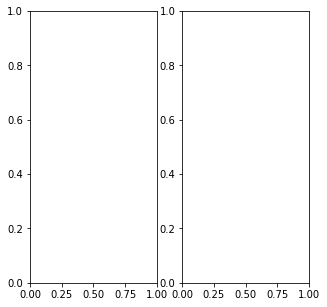

In [59]:
plt.subplots(1,2,figsize=(5,5))
plt.subplot(1,2,3)

In [60]:
real_alt.shape

(50, 100)

TypeError: Invalid shape () for image data

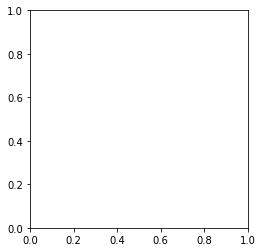

In [61]:
plt.imshow(all_output[3][3])

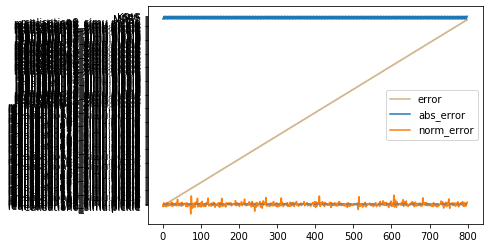

In [9]:
pts_0 = [elt[0] for elt in all_output]
pts_1 = [elt[1] for elt in all_output]
pts_2 = [elt[2] for elt in all_output]


plt.plot(pts_0,color='tan')
plt.plot(pts_1)
plt.plot(pts_2)
plt.legend(['error','abs_error','norm_error'])
plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')
#plt.plot(pts[2])
#plt.plot(pts[0])

Text(0, 0.5, 'Error [m]')

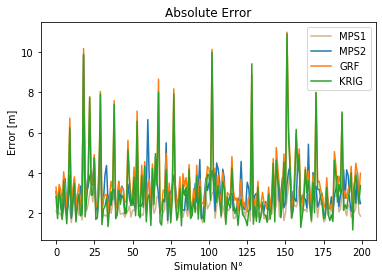

In [10]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


[0, 200, -5, 5]

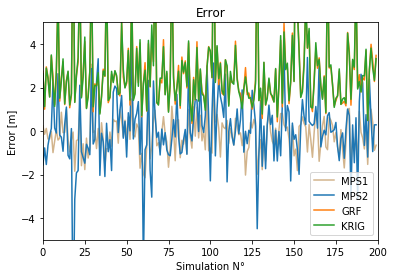

In [16]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.axis([0, 200, -5, 5])

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

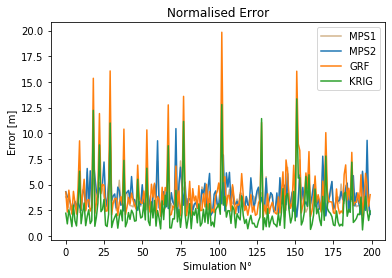

In [12]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')

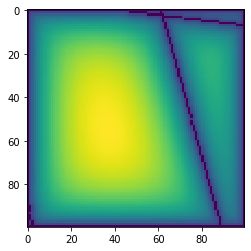

In [17]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Sd.values[9])

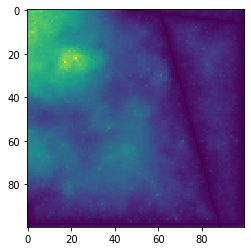

In [18]:
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Sd.values[9])

In [37]:
simulation_name

['realisation0_simu.pickle', 'realisation1_simu.pickle']

In [ ]:
imgplt.d

In [ ]:
all_output = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
it = 0
with open('simulation_output/'+simulation_name,'rb') as file:
    real_alt, simus_sets = pickle.load(file)
    
for simus in simus_sets:        
    pro = indice_calculation(real_alt,simus,'mps')
    all_output.append([name,type_sim[it]] + pro)
    it = it + 1
        
all_output.append([name,type_sim[it]] + pro)
    
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd'])


In [ ]:
simus_sets[2]

In [9]:

simu_alt = simus_sets[0]

somme_simus = np.zeros(np.shape(real_alt))
somme_erreurs = np.zeros(np.shape(real_alt))
sommes_erreurs_abs = np.zeros(np.shape(real_alt))

for i in range(len(simu_alt)):
    somme_simus = np.add(simu_alt[i],somme_simus)
    somme_erreurs = np.add(simu_alt[i]-real_alt,somme_erreurs)
    sommes_erreurs_abs = np.add(np.abs(simu_alt[i]-real_alt),sommes_erreurs_abs)

moyenne_simus = np.divide(somme_simus,len(simu_alt))

standard_dev = np.zeros(np.shape(real_alt))
        
for i in range(len(simu_alt)):
        standard_dev = np.add(standard_dev,np.power(np.subtract(simu_alt[i],moyenne_simus),2))
standard_dev = np.sqrt(np.divide(standard_dev,len(simu_alt)))

moyenne_err3 = np.zeros(np.shape(real_alt))
        
for i in range(len(simu_alt)):
    moyenne_err3 =  np.add(np.power(np.divide((simu_alt[i]-real_alt),standard_dev),2),moyenne_err3)


moyenne_err = np.divide(somme_erreurs,len(simu_alt))
moyenne_err_abs = np.divide(sommes_erreurs_abs,len(simu_alt))
         
            
N = np.size(standard_dev[standard_dev != 0]) * len(simu_alt)
I1= np.mean(moyenne_err[standard_dev != 0])
I2= np.mean(moyenne_err_abs[standard_dev != 0])
I3 = np.sum(moyenne_err3[standard_dev != 0]/(N))

pro = [I1, I2, I3, moyenne_simus, standard_dev]

In [12]:
simus_sets[0]

[array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ..